In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import os
import sys
sys.path.insert(0, "/home/jovyan/sirf-demo/.packages")
import stir_simind_utils as utils
# plotting settings
plt.ion() # interactive 'on' such that plots appear during loops
#%% Import SIRF
import sirf.STIR as spect
import sirf.Utilities
import sirf.Reg as Reg
import numpy as np
import stir
from simind_python_connector import StirSimindAdaptor
import phantomgen as phantom
import numpy as np
import numexpr as ne
ne.set_num_threads(16) # use only 16 threads
import shutil
from pathlib import Path
demo_path = Path("/home/jovyan/sirf-demo/SIRF-demo-1")

Tc99m RC analysis

In [40]:
recon_type = "osem"

tc_input_dir = demo_path / "simind_data" / "tc99m" / "input"
osem_dir = demo_path / "simind_data" / "tc99m" / "recons" / recon_type

nema_act_tc_arr = spect.ImageData(str(tc_input_dir / "nema_tc_act.hv")).as_array()
osem_recon_dict = {str(it):spect.ImageData(str(osem_dir / f"tc99m_sim_{recon_type}_{it}.hv")).as_array() for it in range(10,101,10)}
masks_tc_dict = dict(np.load(tc_input_dir / "masks_tc.npz"))

icf_tc = np.sum(osem_recon_dict["100"]) / np.sum(nema_act_tc_arr)
print(icf_tc)

3462.6267


In [41]:
rc_data = []
for it in range(10,101,10):
    print(f"SUBITERATION {it}")
    rc_it_data = []
    for sp_n in range(1,7):
        mask = masks_tc_dict[f"sphere_{sp_n}"]
        rc = np.sum(osem_recon_dict[str(it)] * mask) / icf_tc / np.sum(nema_act_tc_arr * mask)
        rc_it_data.append(rc)
        print(f"Sphere {sp_n}: {rc}")
    rc_data.append(rc_it_data)
    print()

SUBITERATION 10
Sphere 1: 0.21147966384887695
Sphere 2: 0.36263707280158997
Sphere 3: 0.5620920658111572
Sphere 4: 0.6778534650802612
Sphere 5: 0.7332841753959656
Sphere 6: 0.82700514793396

SUBITERATION 20
Sphere 1: 0.364431768655777
Sphere 2: 0.49494469165802
Sphere 3: 0.6206290125846863
Sphere 4: 0.701673686504364
Sphere 5: 0.752785325050354
Sphere 6: 0.8383325338363647

SUBITERATION 30
Sphere 1: 0.3939318060874939
Sphere 2: 0.5186988115310669
Sphere 3: 0.628472089767456
Sphere 4: 0.7036888003349304
Sphere 5: 0.7554177045822144
Sphere 6: 0.8398239016532898

SUBITERATION 40
Sphere 1: 0.40209275484085083
Sphere 2: 0.5259582996368408
Sphere 3: 0.6307165026664734
Sphere 4: 0.7039778232574463
Sphere 5: 0.756049394607544
Sphere 6: 0.8401461839675903

SUBITERATION 50
Sphere 1: 0.40602919459342957
Sphere 2: 0.5293667316436768
Sphere 3: 0.6316878199577332
Sphere 4: 0.7040426135063171
Sphere 5: 0.7562671303749084
Sphere 6: 0.8402253985404968

SUBITERATION 60
Sphere 1: 0.40850338339805603
Sphe

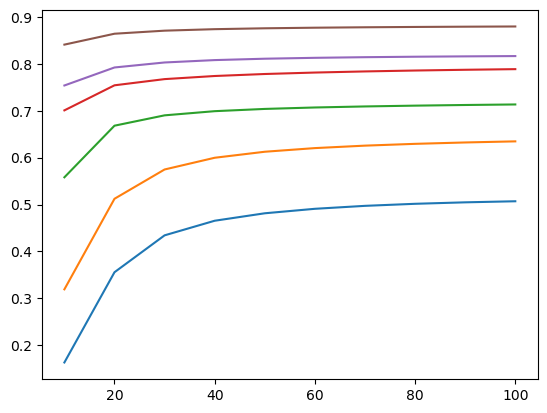

In [39]:
diametre_mm = [13,17,22,28,37,60]
subit = np.arange(10,101,10)
plt.plot(subit, rc_data)

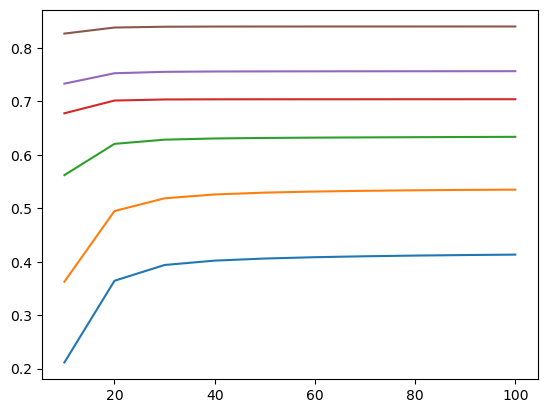

In [42]:
diametre_mm = [13,17,22,28,37,60]
subit = np.arange(10,101,10)
plt.plot(subit, rc_data)

Lu177 RC analysis

In [11]:
lu_input_dir = demo_path / "simind_data" / "lu177" / "input"
osem_dir = demo_path / "simind_data" / "lu177" / "recons" / "osem"

nema_act_lu_arr = spect.ImageData(str(lu_input_dir / "nema_lu_act.hv")).as_array()
osem_recon_dict = {str(it):spect.ImageData(str(osem_dir / f"lu177_sim_osem_{it}.hv")).as_array() for it in range(10,101,10)}
masks_lu_dict = dict(np.load(lu_input_dir / "masks_lu.npz"))

icf_lu = np.sum(osem_recon_dict["100"]) / np.sum(nema_act_lu_arr)
print(icf_lu)

561.52094


In [12]:
mask = masks_tc_dict["sphere_6"]
print(mask)

rc_osem_data = []
for it in range(10,101,10):
    rc = np.sum(osem_recon_dict[str(it)] * mask) / icf_tc / np.sum(nema_act_tc_arr * mask)
    print(rc)

[[[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 ...

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]

 [[0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  ...
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]
  [0 0 0 ... 0 0 0]]]
0.2104026
0.21345396
0.21393183
0.21407144
0.21412724
0.2141576
0.21417928
0.21419764
0.21421449
0.21423046
